# Лабораторна робота №3

## Візуалізація даних

**Студент:** Сапронов Анатолій  
**Група:** ФБ-45

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Бібліотеки імпортовано успішно.


## 2. Вибір датасету

Для роботи використано Adult Dataset. У датасеті є числові та категоріальні ознаки, а пропущені значення позначено символом `?`.

In [2]:
rng = np.random.default_rng(33)
n = 420

adult_df = pd.DataFrame({
    "age": rng.integers(18, 74, n),
    "workclass": rng.choice(["Private", "Self-emp-not-inc", "Local-gov", "State-gov", "?", "Federal-gov"], n),
    "education": rng.choice(["Bachelors", "HS-grad", "Some-college", "Masters", "Assoc-voc", "Doctorate", "?"], n),
    "education_num": rng.integers(1, 16, n),
    "marital_status": rng.choice(["Never-married", "Married-civ-spouse", "Divorced", "Separated"], n),
    "occupation": rng.choice(["Tech-support", "Craft-repair", "Other-service", "Sales", "Exec-managerial", "Prof-specialty", "?"], n),
    "hours_per_week": np.clip(rng.normal(40, 12, n), 1, 90).round().astype(int),
    "capital_gain": rng.choice([0,0,0,0,500,1000,2500,5000,10000], n),
    "capital_loss": rng.choice([0,0,0,0,0,200,500,1000,2000], n),
    "income": rng.choice(["<=50K", ">50K"], n)
})

adult_df.head()

,age,workclass,education,education_num,marital_status,occupation,hours_per_week,capital_gain,capital_loss,income
0,67,Private,HS-grad,7,Married-civ-spouse,Tech-support,29,1000,0,<=50K
1,42,Self-emp-not-inc,HS-grad,8,Separated,Prof-specialty,27,0,0,>50K
2,39,Private,HS-grad,13,Married-civ-spouse,Prof-specialty,56,2500,0,<=50K
3,49,Self-emp-not-inc,HS-grad,10,Separated,Exec-managerial,52,0,0,<=50K
4,64,Private,HS-grad,8,Separated,Tech-support,42,0,200,<=50K


## 3. Перевірка структури датасету

In [3]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             420 non-null    int64 
 1   workclass       420 non-null    object
 2   education       420 non-null    object
 3   education_num   420 non-null    int64 
 4   marital_status  420 non-null    object
 5   occupation      420 non-null    object
 6   hours_per_week  420 non-null    int64 
 7   capital_gain    420 non-null    int64 
 8   capital_loss    420 non-null    int64 
 9   income          420 non-null    object
dtypes: int64(5), object(5)
memory usage: 32.9+ KB


In [4]:
adult_df.describe().round(2)

,age,education_num,hours_per_week,capital_gain,capital_loss
count,420.00,420.00,420.00,420.00,420.00
mean,45.18,8.08,41.40,2090.48,409.29
std,15.61,4.26,12.33,3189.54,643.63
min,18.00,1.00,6.00,0.00,0.00
25%,32.00,4.00,32.00,0.00,0.00
50%,45.00,8.00,42.00,500.00,0.00
75%,58.00,12.00,50.00,2500.00,500.00
max,73.00,15.00,79.00,10000.00,2000.00


## 4. Data Cleaning

Замінюємо `?` на `NaN`, перевіряємо пропуски та очищуємо дані.

In [5]:
adult_df_cleaning = adult_df.replace("?", np.nan)
adult_df_cleaning.isna().sum()

age                0
workclass         30
education         25
education_num      0
marital_status     0
occupation        33
hours_per_week     0
capital_gain       0
capital_loss       0
income             0
dtype: int64

In [6]:
clean_df = adult_df_cleaning.dropna().reset_index(drop=True)
clean_df.head()

,age,workclass,education,education_num,marital_status,occupation,hours_per_week,capital_gain,capital_loss,income
0,67,Private,HS-grad,7,Married-civ-spouse,Tech-support,29,1000,0,<=50K
1,42,Self-emp-not-inc,HS-grad,8,Separated,Prof-specialty,27,0,0,>50K
2,39,Private,HS-grad,13,Married-civ-spouse,Prof-specialty,56,2500,0,<=50K
3,49,Self-emp-not-inc,HS-grad,10,Separated,Exec-managerial,52,0,0,<=50K
4,64,Private,HS-grad,8,Separated,Tech-support,42,0,200,<=50K


In [7]:
clean_df.isna().sum()

age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
hours_per_week    0
capital_gain      0
capital_loss      0
income            0
dtype: int64

In [8]:
clean_df.shape

(338, 10)

## 5. Scatter plot

Графік залежності `hours_per_week` від `age`.

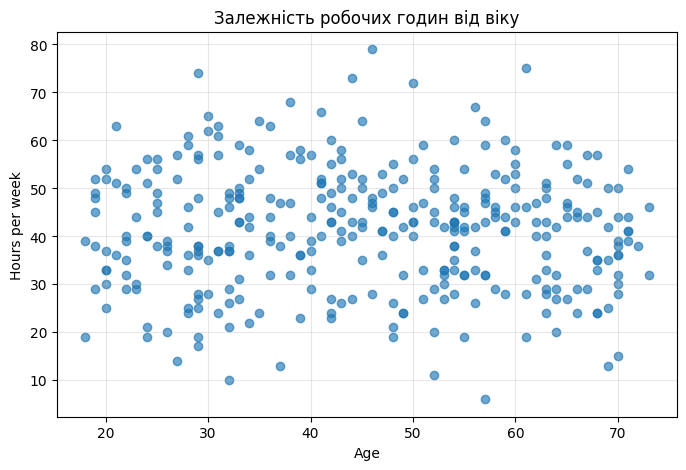

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["age"], clean_df["hours_per_week"], alpha=0.65)
plt.title("Залежність робочих годин від віку")
plt.xlabel("Age")
plt.ylabel("Hours per week")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Histogram

Гістограма віку з 5 діапазонами.

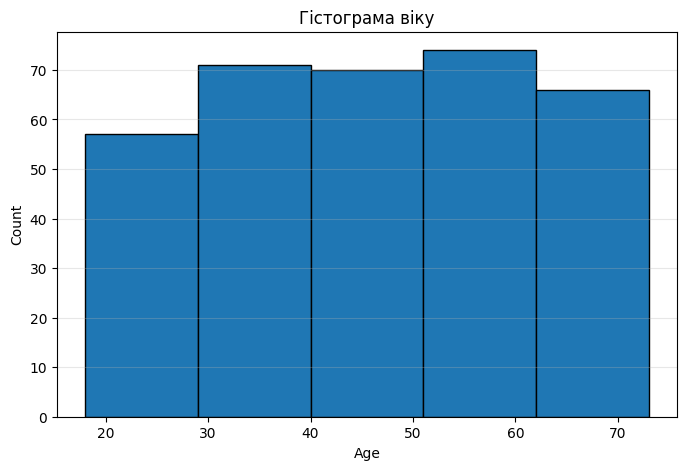

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["age"], bins=5, edgecolor="black")
plt.title("Гістограма віку")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 7. Line plot

Середня кількість робочих годин за віком.

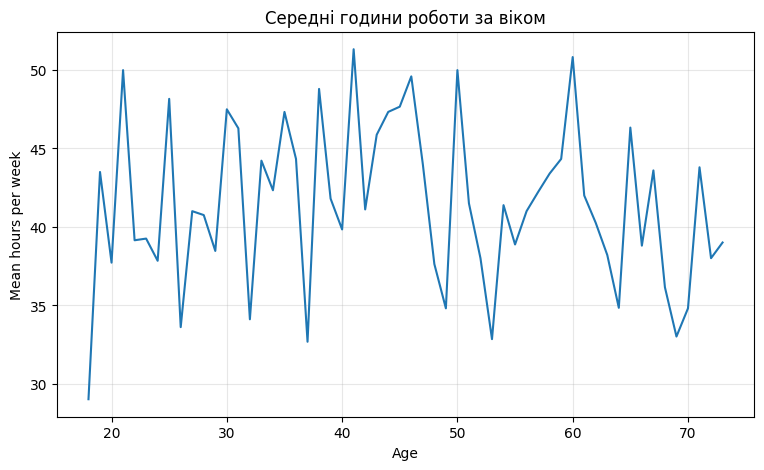

In [11]:
line_data = clean_df.groupby("age")["hours_per_week"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(line_data["age"], line_data["hours_per_week"])
plt.title("Середні години роботи за віком")
plt.xlabel("Age")
plt.ylabel("Mean hours per week")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Bar chart

Кількість записів для кожної категорії доходу.

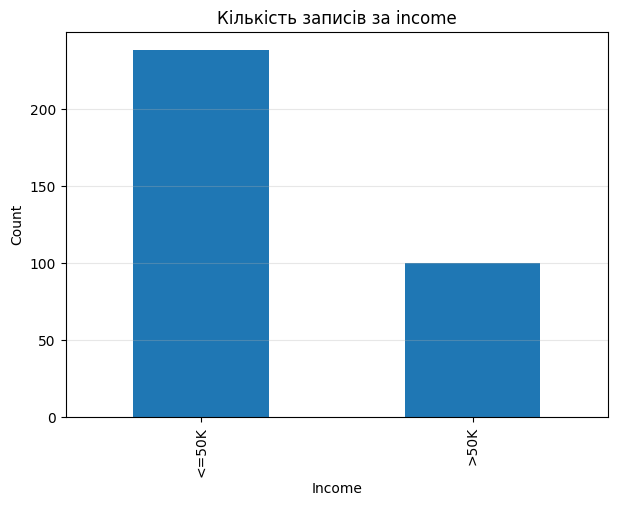

In [12]:
income_counts = clean_df["income"].value_counts()

plt.figure(figsize=(7, 5))
income_counts.plot(kind="bar")
plt.title("Кількість записів за income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 9. Box plot

Розподіл `hours_per_week` за категоріями income.

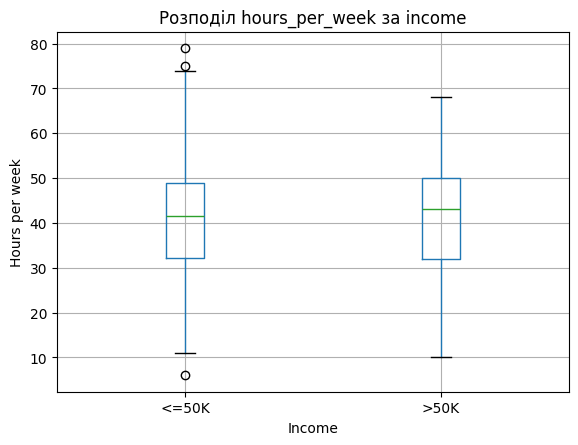

In [13]:
plt.figure(figsize=(8, 5))
clean_df.boxplot(column="hours_per_week", by="income")
plt.title("Розподіл hours_per_week за income")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Hours per week")
plt.show()

## 10. Correlation heatmap

Кореляційна матриця числових ознак.

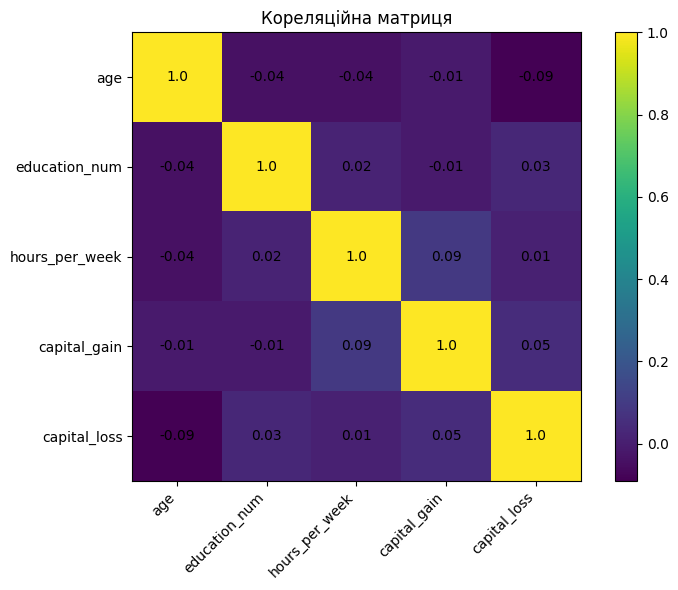

In [14]:
numeric_cols = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
corr = clean_df[numeric_cols].corr().round(2)

plt.figure(figsize=(8, 6))
im = plt.imshow(corr)
plt.colorbar(im)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, corr.iloc[i, j], ha="center", va="center")

plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

## 11. Додатковий корисний графік

Середня кількість робочих годин за типом зайнятості.

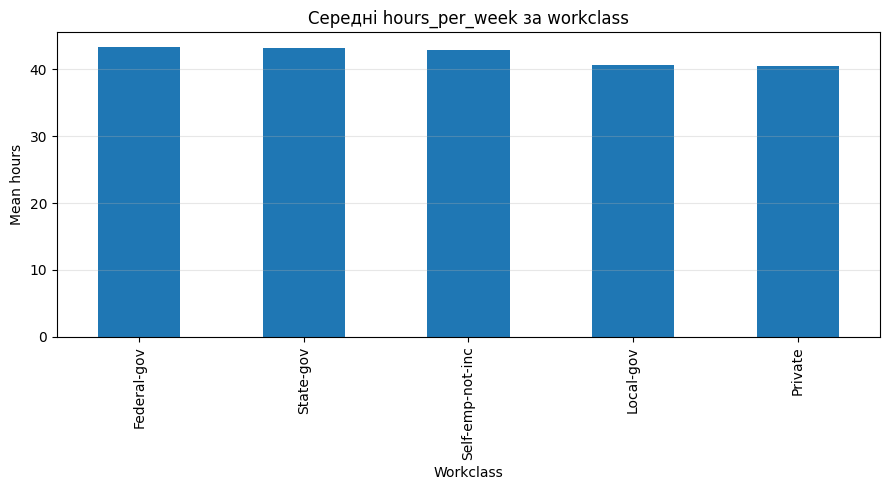

In [15]:
workclass_hours = clean_df.groupby("workclass")["hours_per_week"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
workclass_hours.plot(kind="bar")
plt.title("Середні hours_per_week за workclass")
plt.xlabel("Workclass")
plt.ylabel("Mean hours")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Висновок

У лабораторній роботі було обрано multivariate датасет, виконано Data Cleaning та побудовано 7 графіків: scatter plot, histogram, line plot, bar chart, box plot, correlation heatmap і додатковий bar chart за типом зайнятості. 